In [1]:
from ParticleInitial import *
from Spacepoint import *
from Plots import *
from Wedge import *
from PoleRegion import *
from MathFunctions import *
from SpacepointGenerator import *
import random

In [2]:
particles_initial = ParticleInitial.read_from_csv('../../TestData/PythonToolsDemo/particles_initial_single.csv')
print(particles_initial[0])

spacepoints = Spacepoint.read_from_csv('../../TestData/PythonToolsDemo/spacepoints_single.csv')
print(spacepoints[0])

ParticleInitial(event_id=0, particle_id=4503599644147712, particle_type=13, process=0, vx=-0.0120003, vy=-9.48547e-05, vz=-15.1166, vt=-1.45888, px=-4.42939, py=5.41368, pz=2.34523, m=0.105658, q=-1.0, eta=0.329298, phi=2.25653, pt=6.99481, p=7.3775, vertex_primary_id=1, vertex_secondary_id=0, generation=1, sub_particle_id=0)
Spacepoint(event_id=0, measurement_id=0, geometry_id=1224979236083774208, x=-20.7658, y=25.3002, z=-4.12703, var_r=4.21422e-05, var_z=0.000225)


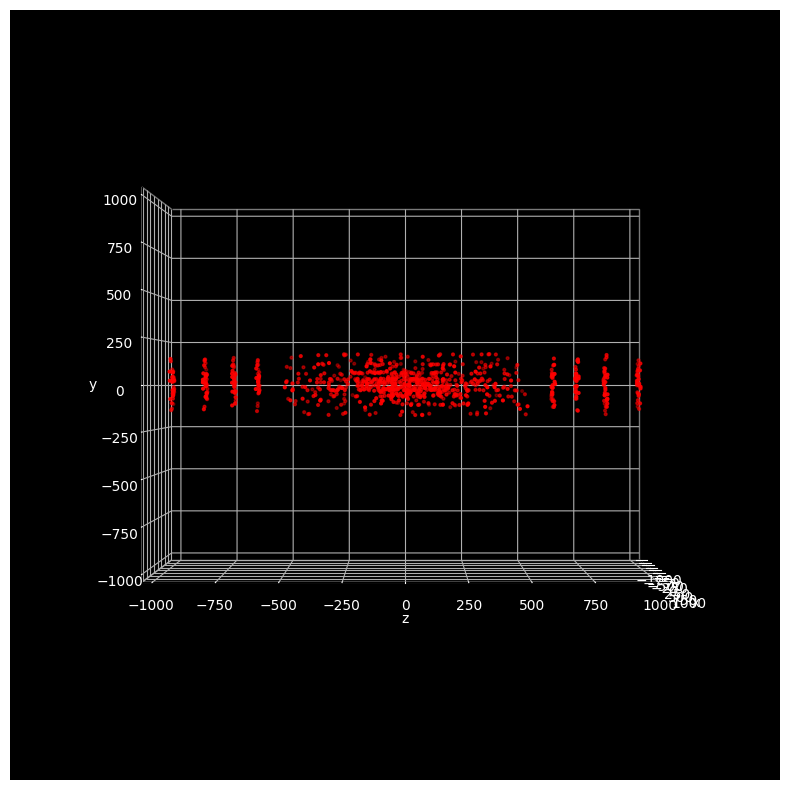

In [3]:
perspective = {'elev': 0, 'azim': 0, 'roll': 0}
detector_plot = DetectorPlot(max_abs_xy=1000, max_abs_z=1000, perspective=perspective)
detector_plot.plot_spacepoints(random.sample(spacepoints, 1000))

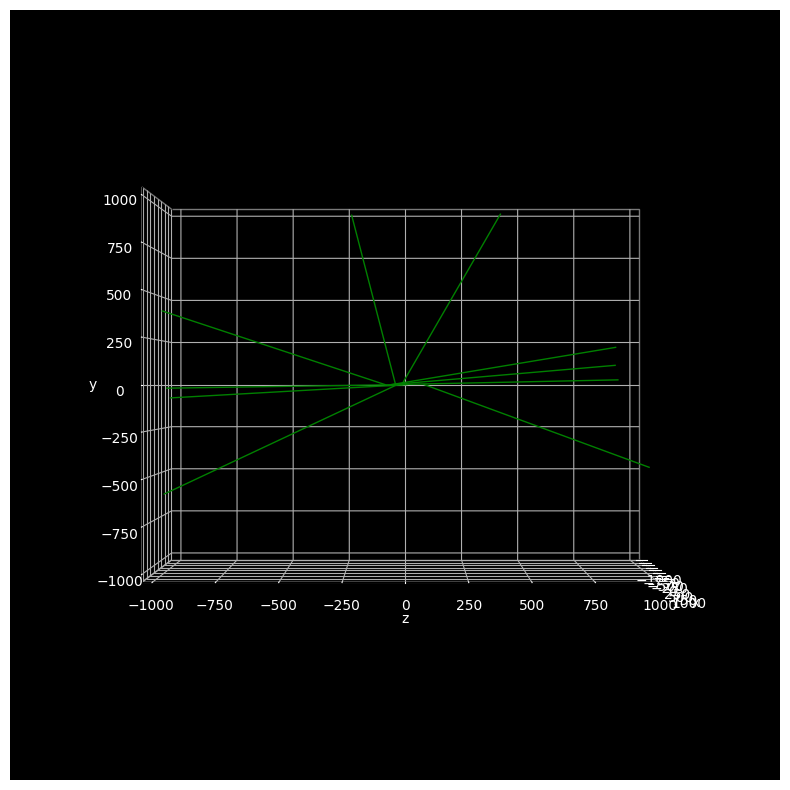

In [4]:
detector_plot = DetectorPlot(max_abs_xy=1000, max_abs_z=1000, perspective=perspective)
detector_plot.plot_particles((particles_initial[:10]), size=1)

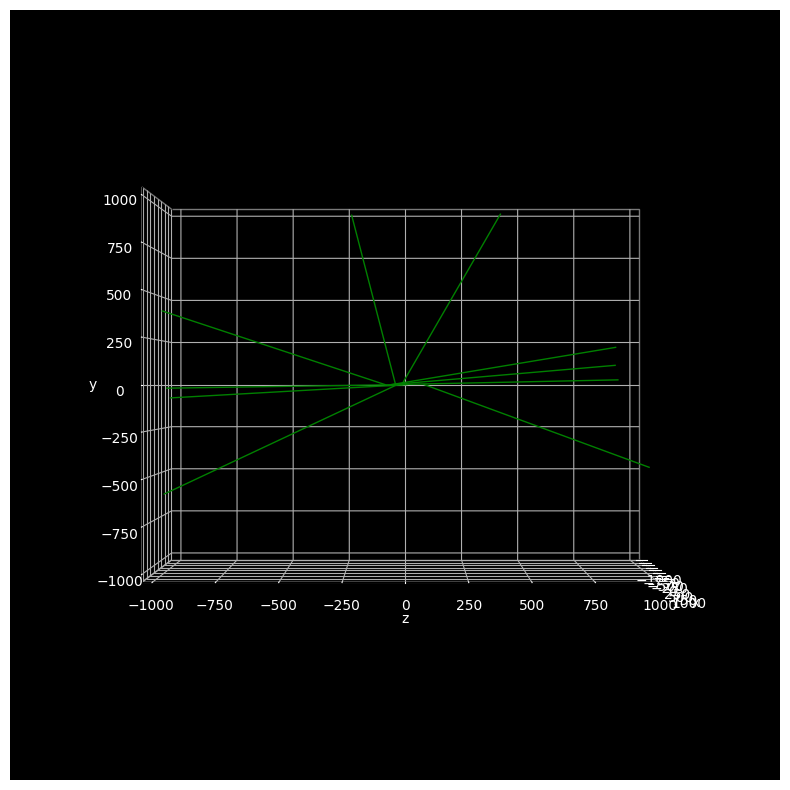

In [5]:
detector_plot = DetectorPlot(max_abs_xy=1000, max_abs_z=1000, perspective=perspective)
detector_plot.plot_particles((particles_initial[:10]), size=1)


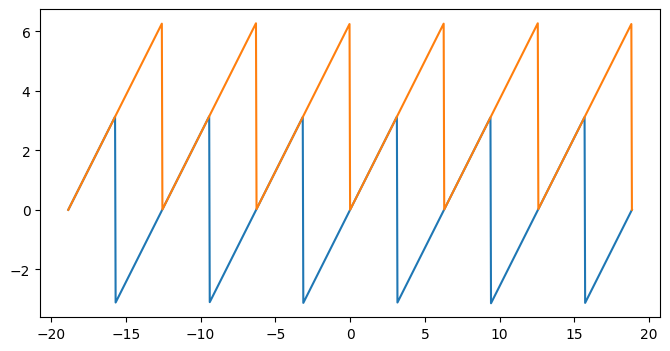

In [6]:
def angle_wrap(angle):
    return math.fmod(angle + math.pi, 2 * math.pi) + (-1 + 2 * (1 if angle + math.pi < 0 else 0)) * math.pi

def angle_wrap_2pi(angle):
    return angle - 2.0 * math.pi * math.floor(angle / (2.0 * math.pi))

def uniform_range(min_value, max_value, num_points):
    return [min_value + i * (max_value - min_value) / (num_points - 1) for i in range(num_points)]

figure_size = (8, 4)
figure = plt.figure(figsize=figure_size)
ax = figure.gca()
test_range = uniform_range(-6 * math.pi, 6 * math.pi, 1001)
ax.plot(test_range, [angle_wrap(i) for i in test_range])
ax.plot(test_range, [angle_wrap_2pi(i) for i in test_range])

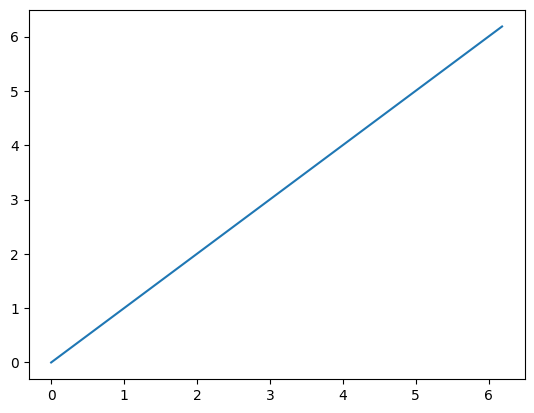

In [7]:
def atan2_2pi(y, x):
    return angle_wrap_2pi(math.atan2(y, x))

phi = [i / 64 * 2 * math.pi for i in range(64)]
x = [math.cos(angle) for angle in phi]
y = [math.sin(angle) for angle in phi]
phi_recalculated = [atan2_2pi(y, x) for x, y in zip(x, y)]
plt.plot(phi, phi_recalculated)

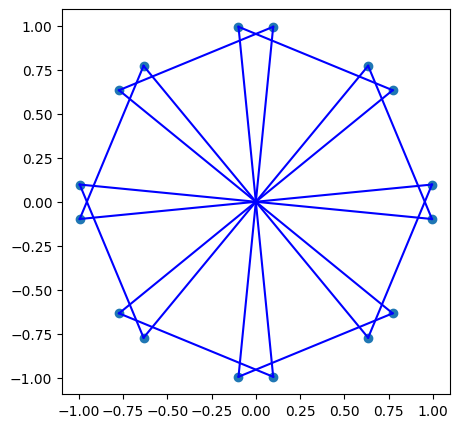

In [8]:
def uniform_range_split(num_ranges, min_range, max_range, margin):
    boundaries = uniform_range(min_range, max_range, num_ranges + 1)
    return [(boundaries[i] - margin, boundaries[i + 1] + margin) for i in range(num_ranges)]

figure_size = (5, 5)
figure = plt.figure(figsize=figure_size)
ax = figure.gca()

ranges = uniform_range_split(8, 0, 2 * math.pi, 2 * math.pi / 64)

outermost_points = []
for (range_min, range_max) in ranges:
    range_min_x = math.cos(range_min) 
    range_min_y = math.sin(range_min)
    range_max_x = math.cos(range_max)
    range_max_y = math.sin(range_max)
    outermost_points.append((range_min_x, range_min_y))
    outermost_points.append((range_max_x, range_max_y))
    plt.plot([0, range_min_x], [0, range_min_y], c='blue')
    plt.plot([0, range_max_x], [0, range_max_y], c='blue')
    plt.plot([range_min_x, range_max_x], [range_min_y, range_max_y], c='blue')
plt.scatter([i[0] for i in outermost_points], [i[1] for i in outermost_points])

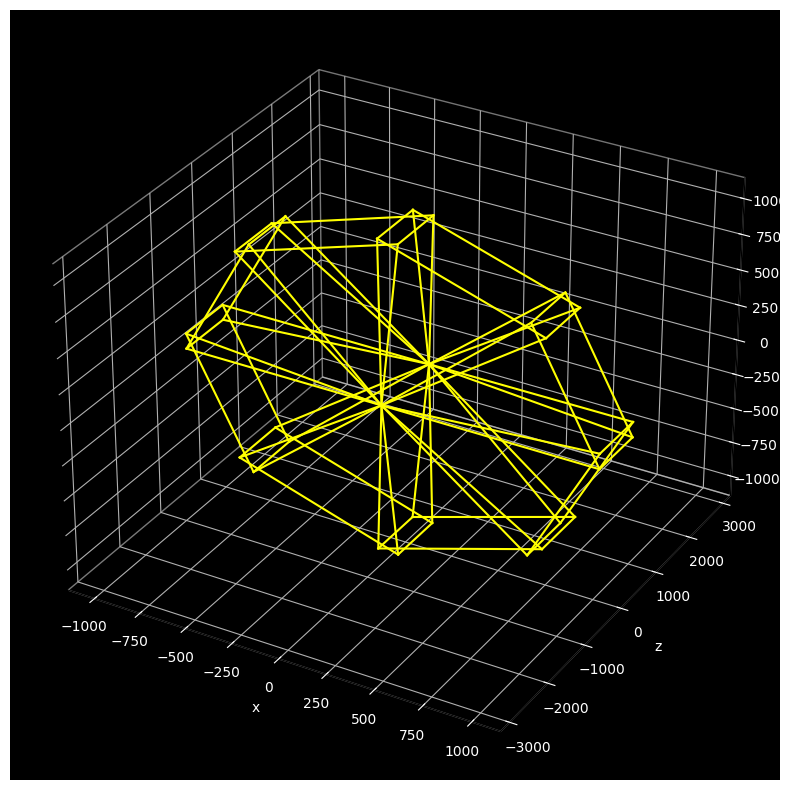

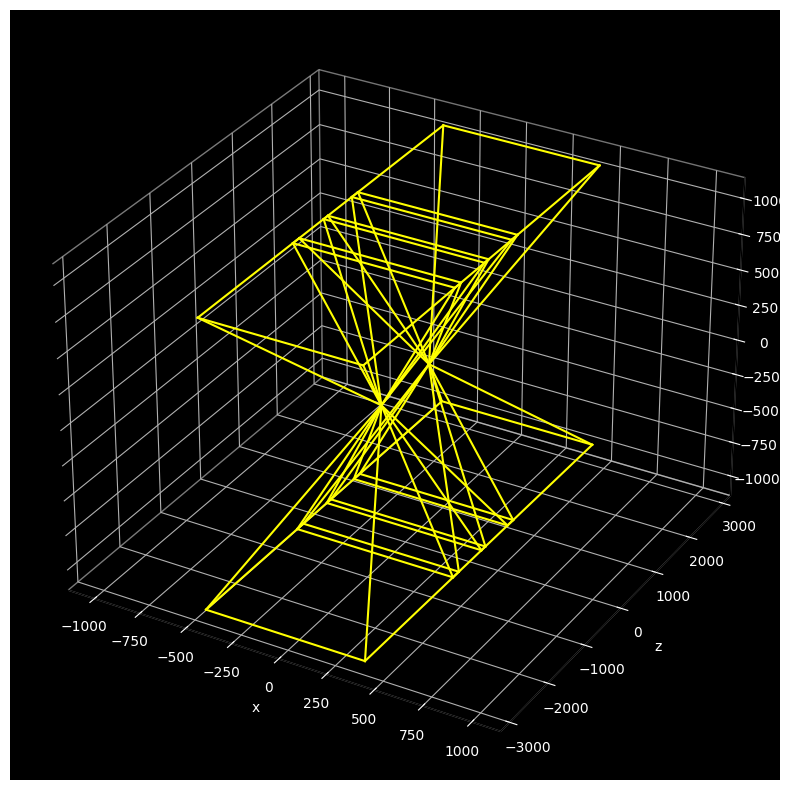

In [9]:
max_abs_z = 3100
max_abs_xy = 1100

z_ranges = [(angle_wrap_2pi(i[0]), angle_wrap_2pi(i[1])) for i in uniform_range_split(8, 0, 2 * math.pi, 2 * math.pi / 128)]
wedges = [Wedge(z_range[0], z_range[1], 3 * 1 / 8 * math.pi, 5 * 1 / 8 * math.pi, 2 * 0.2 * max_abs_z) for z_range in z_ranges]

detector_plot = DetectorPlot()
for wedge in wedges:
    detector_plot.plot_wedge(wedge)

x_ranges = uniform_range_split(4, 8 / 64 * math.pi, 56 / 64 * math.pi, 2 * math.pi / 128)
x_ranges.extend(uniform_range_split(4, 72 / 64 * math.pi, 120 / 64 * math.pi, 2 * math.pi / 128))
wedges = [Wedge(3 * 1 / 8 * math.pi, 5 * 1 / 8 * math.pi, x_range[0], x_range[1], 2 * 0.2 * max_abs_z) for x_range in x_ranges]

detector_plot = DetectorPlot()
for wedge in wedges:
    detector_plot.plot_wedge(wedge)

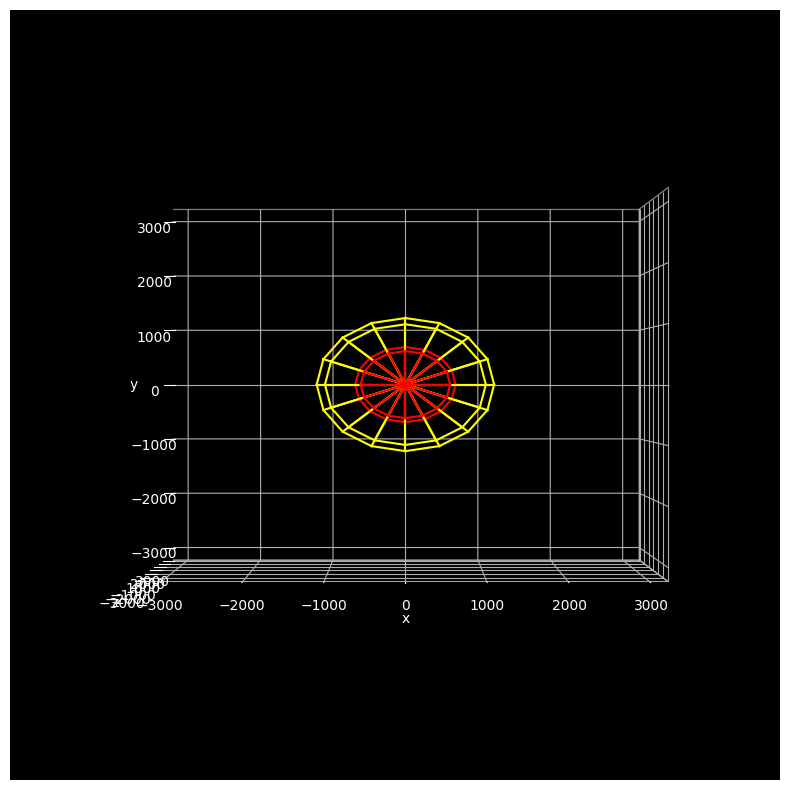

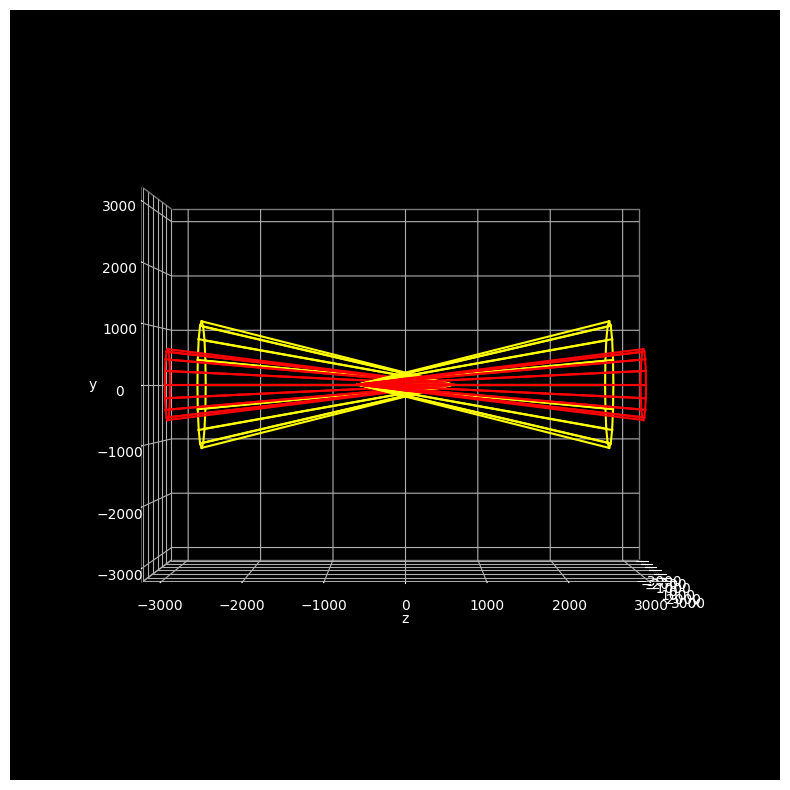

In [10]:
max_abs_z = 3100
max_abs_xy = 1100

pole_region = PoleRegion(56 / 64 * math.pi, 2 * 0.2 * max_abs_z)
pole_region2 = PoleRegion(60 / 64 * math.pi, 2 * 0.2 * max_abs_z)
pole_region3 = PoleRegion(8 / 64 * math.pi, 2 * 0.2 * max_abs_z)
pole_region4 = PoleRegion(4 / 64 * math.pi, 2 * 0.2 * max_abs_z)

detector_plot = DetectorPlot(keep_aspect_ratio=True)
perspective = {'elev': 0, 'azim': 270, 'roll': 0}
detector_plot.ax.view_init(elev=0, azim=270, roll=0)
num_rays = 16
detector_plot.plot_pole_region(pole_region, num_rays=num_rays)
detector_plot.plot_pole_region(pole_region2, num_rays=num_rays, color="red")
detector_plot.plot_pole_region(pole_region3, num_rays=num_rays)
detector_plot.plot_pole_region(pole_region4, num_rays=num_rays, color="red")

detector_plot = DetectorPlot(keep_aspect_ratio=True)
perspective = {'elev': 0, 'azim': 0, 'roll': 0}
detector_plot.ax.view_init(elev=0, azim=0, roll=0)
num_rays = 16
detector_plot.plot_pole_region(pole_region, num_rays=num_rays)
detector_plot.plot_pole_region(pole_region2, num_rays=num_rays, color="red")
detector_plot.plot_pole_region(pole_region3, num_rays=num_rays)
detector_plot.plot_pole_region(pole_region4, num_rays=num_rays, color="red")


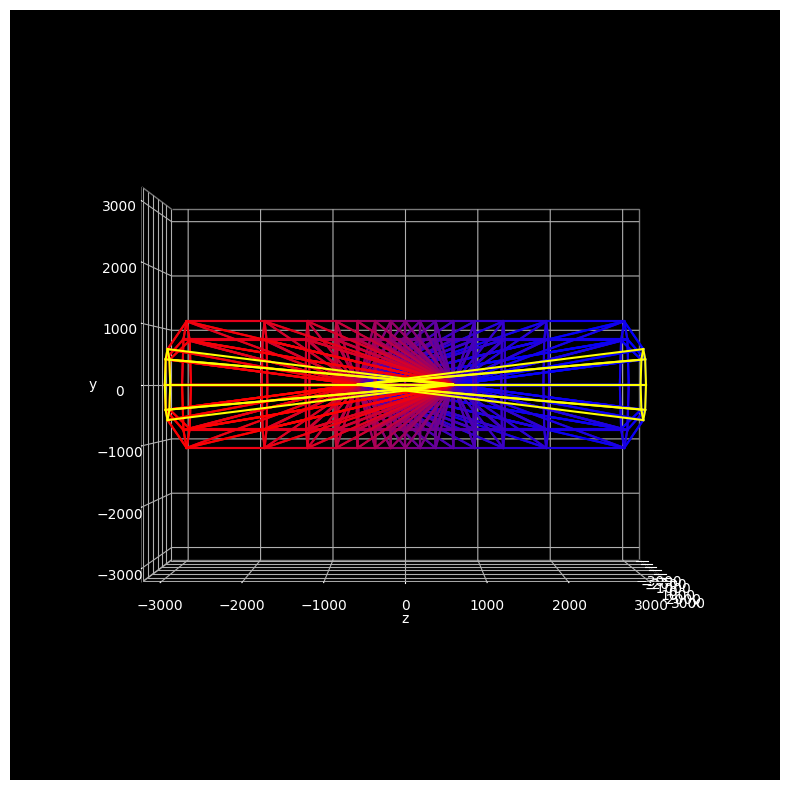

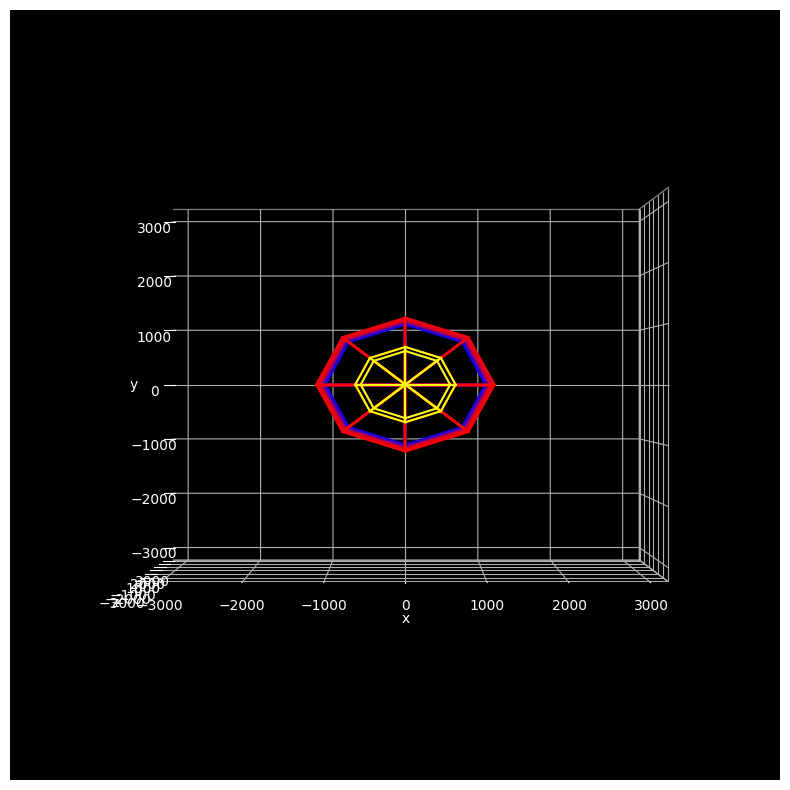

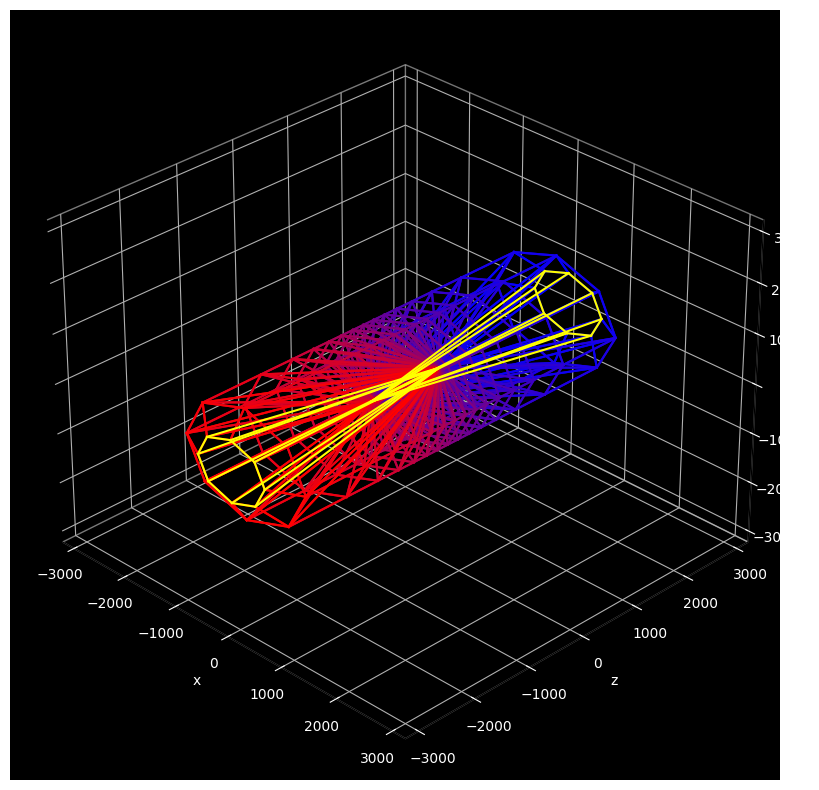

In [11]:
def get_wedges(num_z_ranges, num_x_ranges, min_x_angle, interaction_region_width, margin=0):
    z_ranges = [(angle_wrap_2pi(i[0]), angle_wrap_2pi(i[1])) for i in uniform_range_split(num_z_ranges, 0, 2 * math.pi, margin)]
    x_ranges = uniform_range_split(num_x_ranges, min_x_angle, math.pi - min_x_angle, margin)

    wedges = []
    for x_range in x_ranges:
        for z_range in z_ranges:
            wedges.append(Wedge(z_range[0], z_range[1], x_range[0], x_range[1], interaction_region_width))
    return wedges

def get_pole_regions(min_x_angle, interaction_region_width, margin=0):
    return [
        PoleRegion(min_x_angle + margin, interaction_region_width),
        PoleRegion(math.pi - min_x_angle - margin, interaction_region_width)
    ]

def get_wedges_and_pole_regions(num_z_ranges, num_x_ranges, min_x_angle, interaction_region_width, margin=0):
    return get_wedges(num_z_ranges, num_x_ranges, min_x_angle, interaction_region_width, margin), get_pole_regions(min_x_angle, interaction_region_width, margin)

num_z_ranges = 8
num_x_ranges = 16
min_x_angle = 4 / 64 * math.pi
interaction_region_width = 2 * 0.2 * 3100
wedges, pole_regions = get_wedges_and_pole_regions(num_z_ranges, num_x_ranges, min_x_angle, interaction_region_width)

perspectives = []
perspectives.append({'elev': 0, 'azim': 0, 'roll': 0})
perspectives.append({'elev': 0, 'azim': 270, 'roll': 0})
perspectives.append({'elev': 30, 'azim': -45, 'roll': 0})
for perspective in perspectives:
    detector_plot = DetectorPlot(keep_aspect_ratio=True, perspective=perspective)
    for i in range(len(wedges)):
        red = (i / (len(wedges) - 1))
        blue = 1 - red
        detector_plot.plot_wedge(wedges[i], color=(red, 0, blue))
    for pole_region in pole_regions:
        detector_plot.plot_pole_region(pole_region, num_rays=num_z_ranges, color='yellow')

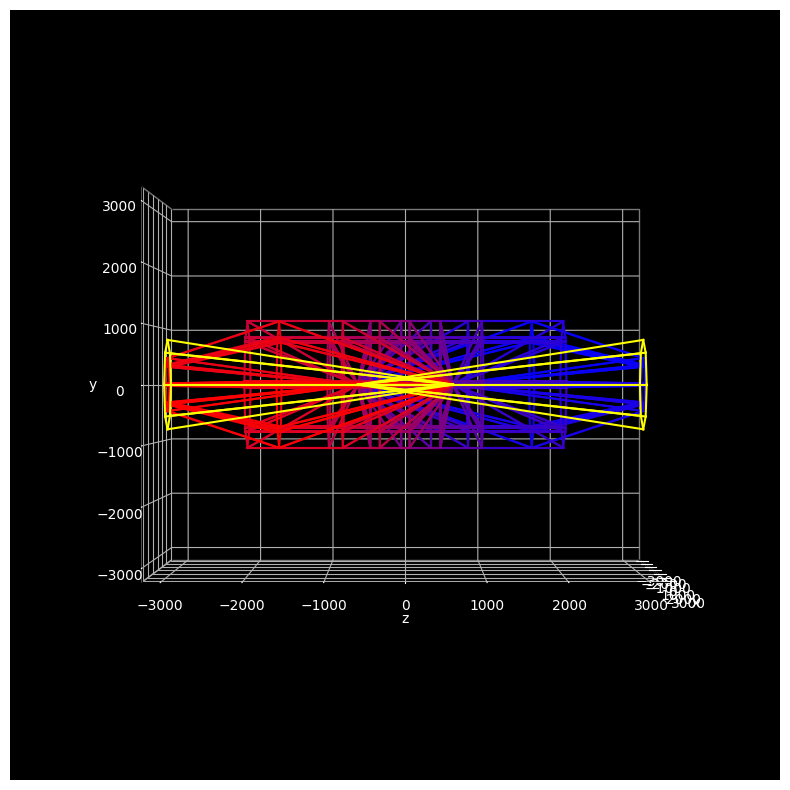

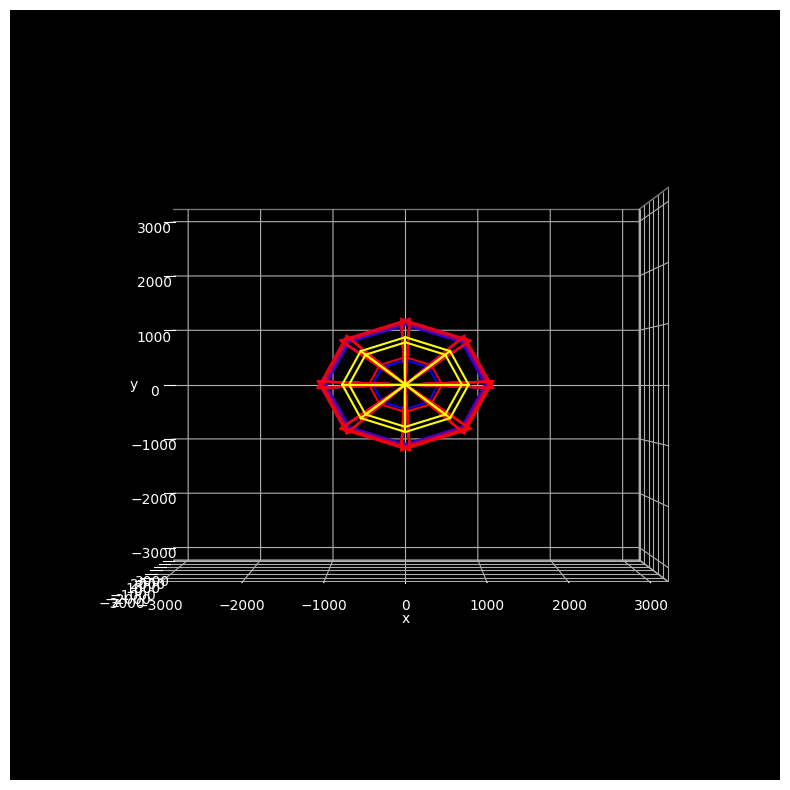

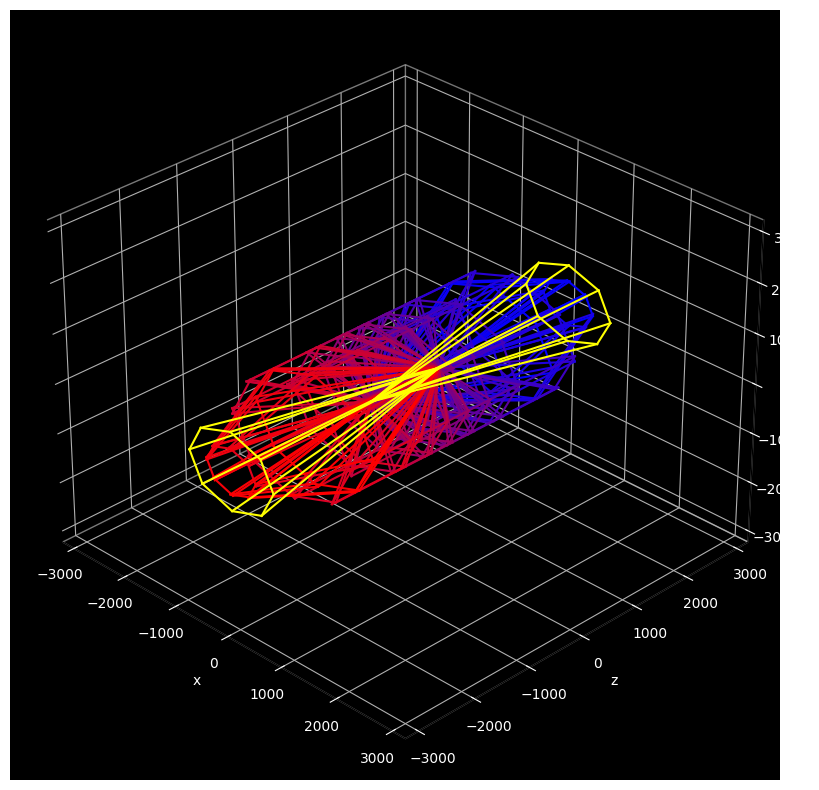

In [12]:
num_z_ranges = 8
num_x_ranges = 8
min_x_angle = 4 / 64 * math.pi
interaction_region_width = 2 * 0.2 * 3100
margin = 4 / 256 * math.pi
wedges, pole_regions = get_wedges_and_pole_regions(num_z_ranges, num_x_ranges, min_x_angle, interaction_region_width, margin)

perspectives = []
perspectives.append({'elev': 0, 'azim': 0, 'roll': 0})
perspectives.append({'elev': 0, 'azim': 270, 'roll': 0})
perspectives.append({'elev': 30, 'azim': -45, 'roll': 0})
for perspective in perspectives:
    detector_plot = DetectorPlot(keep_aspect_ratio=True, perspective=perspective)
    for i in range(len(wedges)):
        red = (i / (len(wedges) - 1))
        blue = 1 - red
        detector_plot.plot_wedge(wedges[i], color=(red, 0, blue))
    for pole_region in pole_regions:
        detector_plot.plot_pole_region(pole_region, num_rays=num_z_ranges, color='yellow')

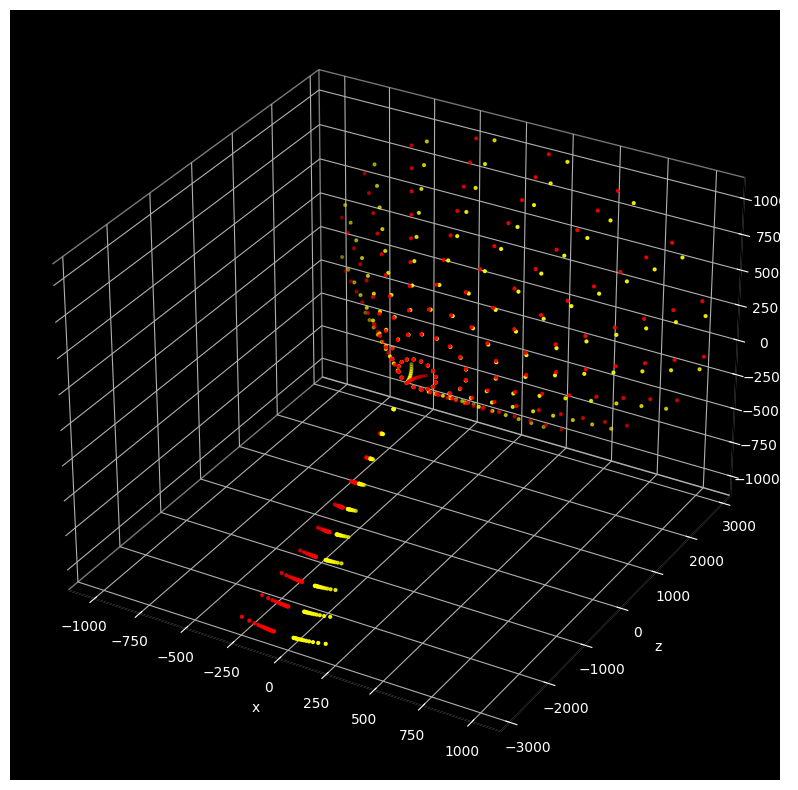

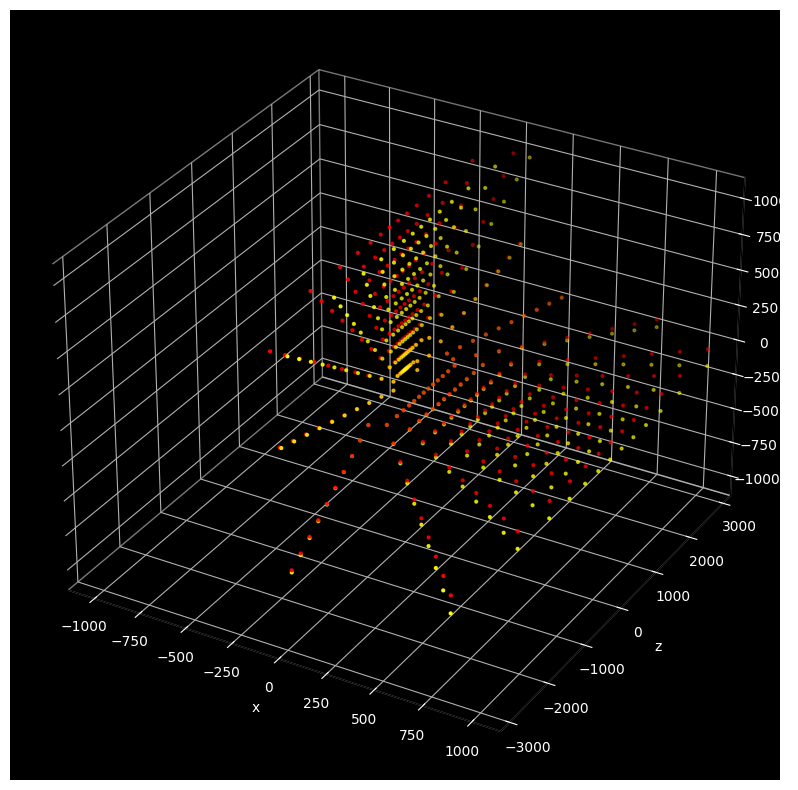

In [ ]:
x_angle = math.pi / 10
z_angle = math.pi / 2
z = 0
r = 10000
num_points = 10

# z_angles check
z_angles = [lerp(0, math.pi * 2, i / 16 + 1 / 32) for i in range(16)]
spacepoints_ccw = [generate_spacepoints(x_angle, z_angle, z, r, counter_clockwise=True, num_points=num_points) for z_angle in z_angles]
spacepoints_ccw = [spacepoint for spacepoint_list in spacepoints_ccw for spacepoint in spacepoint_list]
spacepoints_cw = [generate_spacepoints(x_angle, z_angle, z, r, counter_clockwise=False, num_points=num_points) for z_angle in z_angles]
spacepoints_cw = [spacepoint for spacepoint_list in spacepoints_cw for spacepoint in spacepoint_list]
detector_plot = DetectorPlot()
detector_plot.plot_spacepoints(spacepoints_ccw, color='red')
detector_plot.plot_spacepoints(spacepoints_cw, color='yellow')

# r check
rs = [lerp(2000, 10000, i / 16 + 1 / 32) for i in range(16)]
spacepoints_ccw = [generate_spacepoints(x_angle + math.pi, z_angle, z, r, counter_clockwise=True, num_points=num_points) for r in rs]
spacepoints_ccw = [spacepoint for spacepoint_list in spacepoints_ccw for spacepoint in spacepoint_list]
spacepoints_cw = [generate_spacepoints(x_angle + math.pi, z_angle, z, r, counter_clockwise=False, num_points=num_points) for r in rs]
spacepoints_cw = [spacepoint for spacepoint_list in spacepoints_cw for spacepoint in spacepoint_list]
# detector_plot = DetectorPlot()
detector_plot.plot_spacepoints(spacepoints_ccw, color='red')
detector_plot.plot_spacepoints(spacepoints_cw, color='yellow')

# x_angles check
x_angles = [lerp(0, math.pi, i / 16 + 1 / 32) for i in range(16)]
spacepoints_ccw = [generate_spacepoints(x_angle, z_angle, z, r, counter_clockwise=True, num_points=num_points) for x_angle in x_angles]
spacepoints_ccw = [spacepoint for spacepoint_list in spacepoints_ccw for spacepoint in spacepoint_list]
spacepoints_cw = [generate_spacepoints(x_angle, z_angle, z, r, counter_clockwise=False, num_points=num_points) for x_angle in x_angles]
spacepoints_cw = [spacepoint for spacepoint_list in spacepoints_cw for spacepoint in spacepoint_list]
detector_plot = DetectorPlot()
detector_plot.plot_spacepoints(spacepoints_ccw, color='red')
detector_plot.plot_spacepoints(spacepoints_cw, color='yellow')

# z check
zs = [lerp(800, -800, i / 16 + 1 / 32) for i in range(16)]
x_angles = [lerp(0, math.pi, i / 16 + 1 / 32) for i in range(16)]
spacepoints_ccw = [generate_spacepoints(x_angle, z_angle - math.pi / 2, z, r, counter_clockwise=True, num_points=num_points) for x_angle, z in zip(x_angles, zs)]
spacepoints_ccw = [spacepoint for spacepoint_list in spacepoints_ccw for spacepoint in spacepoint_list]
spacepoints_cw = [generate_spacepoints(x_angle, z_angle - math.pi / 2, z, r, counter_clockwise=False, num_points=num_points) for x_angle, z in zip(x_angles, zs)]
spacepoints_cw = [spacepoint for spacepoint_list in spacepoints_cw for spacepoint in spacepoint_list]
# detector_plot = DetectorPlot()
detector_plot.plot_spacepoints(spacepoints_ccw, color='red')
detector_plot.plot_spacepoints(spacepoints_cw, color='yellow')


Spacepoint(event_id=0, measurement_id=None, geometry_id=None, x=-70.12313657240793, y=84.75036111667214, z=21.764336276833724, var_r=None, var_z=None)
Spacepoint(event_id=0, measurement_id=None, geometry_id=None, x=-141.17426590977266, y=168.72425594145534, z=58.645272553667446, var_r=None, var_z=None)
Spacepoint(event_id=0, measurement_id=None, geometry_id=None, x=-213.14479091213252, y=251.91152373553177, z=95.52620883050116, var_r=None, var_z=None)
Spacepoint(event_id=0, measurement_id=None, geometry_id=None, x=-286.0260032337719, y=334.30209894099335, z=132.40714510733488, var_r=None, var_z=None)
Spacepoint(event_id=0, measurement_id=None, geometry_id=None, x=-359.80908433692184, y=415.88601239876334, z=169.2880813841686, var_r=None, var_z=None)
Spacepoint(event_id=0, measurement_id=None, geometry_id=None, x=-434.4851065587891, y=496.65339255485014, z=206.16901766100233, var_r=None, var_z=None)
Spacepoint(event_id=0, measurement_id=None, geometry_id=None, x=-510.0450341917949, y=57

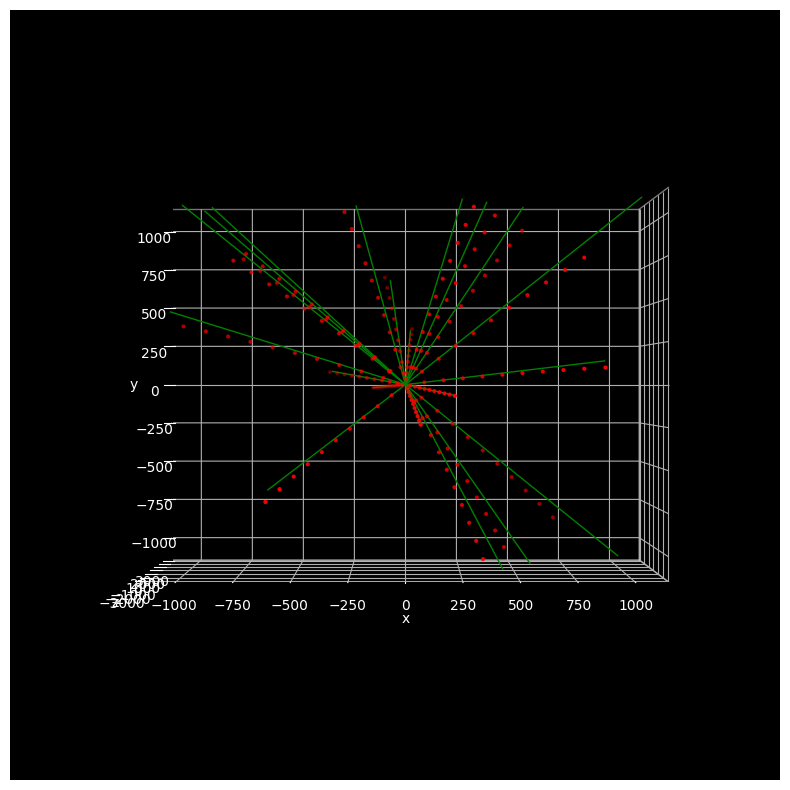

In [15]:
perspective = {'elev': 0, 'azim': -90, 'roll': 0}
detector_plot = DetectorPlot(perspective=perspective)
detector_plot.plot_particles((particles_initial[:20]), size=1)

particle_spacepoints = [generate_spacepoints(particle_initial=particle, r=10000) for particle in particles_initial[:20]]
particle_spacepoints = [spacepoint for spacepoint_list in particle_spacepoints for spacepoint in spacepoint_list]
detector_plot.plot_spacepoints(particle_spacepoints)
